# Whisk/lick occupancy by epoch and engagement state, across sessions

Scalable version of the single-session diagnostic: set `N_SESSIONS` below to control how many
sessions to include (`None` = all available). Each session contributes one time-pooled proportion
per (epoch, engagement state); error bars are SEM **across sessions** (not within-session bin
noise), so sessions are the unit of replication.

Per-session results are cached to `whisk_lick_epoch_cache.pqt` so a rerun only fetches sessions
that aren't already cached (~6s/session fresh from Google Drive, instant from cache).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

prefix = '/Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/'
BEH_DIR = '/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/states_files_old/'
CACHE_PATH = prefix + 'GLM-HMM/whisk_lick_epoch_cache.pqt'

N_SESSIONS = None  # None = use all available sessions; set an int to limit (e.g. for a quick test)

EPOCHS = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']
STATES = ['state1', 'state2']

## Load GLM-HMM engagement states and locate behavioral files

Same matching as `syllables_vs_engagement.ipynb`: `10_states_file_<eid>_<mouse>` in
`states_files_old`, validated against `states_df` earlier (100% contrast/block match on an
example session).

In [2]:
lda = pd.read_pickle(prefix + 'clustering/mouse_LDA_5_bins_cut19-06-2026').rename(columns={0: 'lda_1'})
states_df = pd.read_parquet(prefix + 'GLM-HMM/merged_behavioral_and_states.pqt')
states_df['dominant_state'] = np.where(states_df['p_state1'] >= 0.5, 'state1', 'state2')

matched_sessions = sorted(set(lda['session']) & set(states_df['eid']))

beh_files = {}
for fname in os.listdir(BEH_DIR):
    if fname.startswith('10_states_file_'):
        eid = fname[len('10_states_file_'):].split('_')[0]
        beh_files[eid] = fname

available = [e for e in matched_sessions if e in beh_files]
print(f"Sessions with a behavioral states file: {len(available)} / {len(matched_sessions)}")

session_eids = available if N_SESSIONS is None else available[:N_SESSIONS]
print(f"Using {len(session_eids)} sessions (N_SESSIONS={N_SESSIONS})")

Sessions with a behavioral states file: 244 / 244
Using 244 sessions (N_SESSIONS=None)


## Per-session, per-epoch, per-engagement-state proportions

`whisk`/`lick` decoded from `identifiable_states` (digit 2 = whisk, digit 3 = lick), same method
as `1_segmentation/neural_spike_files.ipynb`. Proportions are pooled by time within each session
(total bins in state / total bins), not averaged per trial first.

In [3]:
def load_session_behavior(eid):
    beh = pd.read_parquet(BEH_DIR + beh_files[eid])
    digits = beh['identifiable_states'].str.extract(r'(\d)(\d)(\d)').astype('Int64')
    digits.columns = ['paw', 'whisk', 'lick']
    beh[['paw', 'whisk', 'lick']] = digits
    return beh


def session_epoch_state_proportions(eid):
    """One row per (epoch, dominant_state) present in this session, with time-pooled
    whisk/lick proportions. trial_id <-> states_df row-order alignment validated in
    load_states.ipynb (trial_id - trial_id.min() == row index for a given eid)."""
    beh = load_session_behavior(eid)

    session_states = states_df[states_df['eid'] == eid].reset_index(drop=True)
    trial_id_to_state = dict(zip(session_states.index + beh['trial_id'].min(), session_states['dominant_state']))
    beh['dominant_state'] = beh['trial_id'].map(trial_id_to_state)

    valid = beh.dropna(subset=['trial_id', 'broader_label', 'dominant_state'])
    summary = valid.groupby(['broader_label', 'dominant_state'])[['whisk', 'lick']].mean()
    summary['session'] = eid
    return summary.reset_index()

## Compute (cached: only fetches sessions not already on disk)

In [4]:
def load_cache():
    if os.path.exists(CACHE_PATH):
        return pd.read_parquet(CACHE_PATH)
    return pd.DataFrame(columns=['broader_label', 'dominant_state', 'whisk', 'lick', 'session'])


cache = load_cache()
cached_sessions = set(cache['session'].unique())
missing = [e for e in session_eids if e not in cached_sessions]
print(f"{len(missing)} / {len(session_eids)} sessions need fetching ({len(cached_sessions)} already cached)")

new_summaries = []
for i, eid in enumerate(missing):
    try:
        new_summaries.append(session_epoch_state_proportions(eid))
    except Exception as e:
        print(f"  Skipping {eid}: {e}")
        continue

    if (i + 1) % 20 == 0 or (i + 1) == len(missing):
        print(f"  fetched {i + 1} / {len(missing)}")
        pd.concat([cache] + new_summaries, ignore_index=True).to_parquet(CACHE_PATH)

if new_summaries:
    cache = pd.concat([cache] + new_summaries, ignore_index=True)
    cache.to_parquet(CACHE_PATH)

session_summary = cache[cache['session'].isin(session_eids)].reset_index(drop=True)
print(f"\n{session_summary['session'].nunique()} / {len(session_eids)} sessions available")

0 / 244 sessions need fetching (244 already cached)

244 / 244 sessions available


## Aggregate across sessions (mean ± SEM, session = unit of replication)

In [5]:
agg = session_summary.groupby(['broader_label', 'dominant_state'])[['whisk', 'lick']].agg(['mean', 'sem', 'count'])
agg.columns = ['_'.join(c) for c in agg.columns]
agg = agg.reset_index()
agg

,broader_label,dominant_state,whisk_mean,whisk_sem,whisk_count,lick_mean,lick_sem,lick_count
0,Choice,state1,0.500343,0.011156,244,0.122183,0.00599,244
1,Choice,state2,0.439272,0.013718,241,0.078023,0.006382,241
2,ITI,state1,0.854144,0.005944,244,0.514378,0.009626,244
3,ITI,state2,0.776367,0.00799,241,0.319215,0.010221,241
4,Pre-quiescence,state1,0.745223,0.008906,244,0.117128,0.006825,244
5,Pre-quiescence,state2,0.752911,0.01033,241,0.09655,0.007113,241
6,Quiescence,state1,0.301183,0.012524,244,0.046584,0.004887,244
7,Quiescence,state2,0.282446,0.01249,241,0.036184,0.004727,241


## Proportion of time spent whisking, per epoch per engagement state (mean ± SEM across sessions)

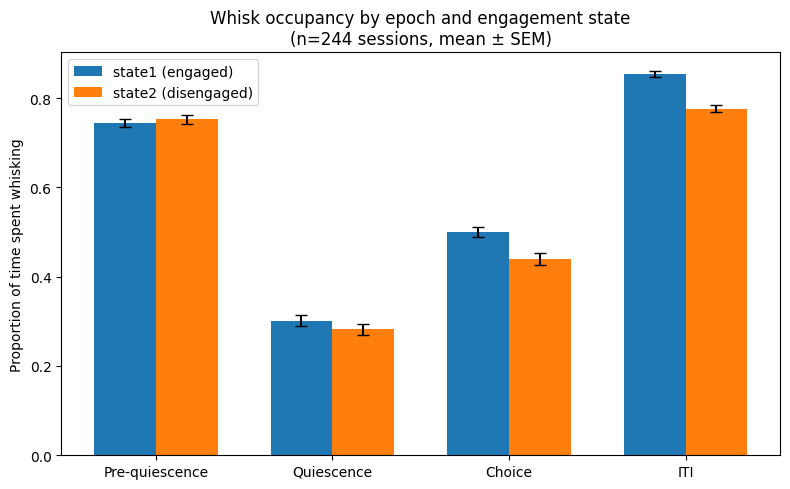

In [6]:
def grouped_bar(agg, metric, ylabel, title):
    x = np.arange(len(EPOCHS))
    width = 0.35
    colors = {'state1': 'tab:blue', 'state2': 'tab:orange'}
    labels = {'state1': 'state1 (engaged)', 'state2': 'state2 (disengaged)'}

    fig, ax = plt.subplots(figsize=(8, 5))
    for i, state in enumerate(STATES):
        sub = agg[agg['dominant_state'] == state].set_index('broader_label').reindex(EPOCHS)
        offset = (i - 0.5) * width
        ax.bar(x + offset, sub[f'{metric}_mean'], width, yerr=sub[f'{metric}_sem'],
               capsize=4, color=colors[state], label=labels[state])
    ax.set_xticks(x)
    ax.set_xticklabels(EPOCHS)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


grouped_bar(agg, 'whisk', 'Proportion of time spent whisking',
            f'Whisk occupancy by epoch and engagement state\n(n={session_summary["session"].nunique()} sessions, mean \u00b1 SEM)')

## Proportion of time spent licking, per epoch per engagement state (mean ± SEM across sessions)

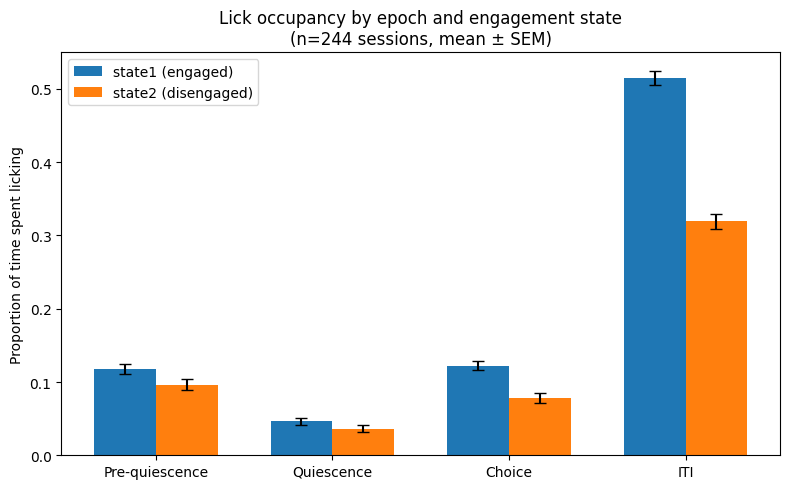

In [7]:
grouped_bar(agg, 'lick', 'Proportion of time spent licking',
            f'Lick occupancy by epoch and engagement state\n(n={session_summary["session"].nunique()} sessions, mean \u00b1 SEM)')

# Correlation with LDA 1

**Caveat before interpreting these**: LDA 1 may be built (at least in some versions of the
pipeline, see `4_mice/LDA_analyses_pipeline_CORRECTED.ipynb`'s `binarize()` step) directly from
session-averaged whisk/lick/paw syllable occupancy. So a raw correlation between whisk/lick
occupancy and LDA 1 risks being partly circular (LDA 1 "rediscovering" its own input). This
does NOT apply to the earlier `state_ratio`/`stickiness` vs LDA 1 correlations in
`load_states.ipynb` - those come from the GLM-HMM fit on choice/contrast data, a separate
pipeline that never saw whisk/lick/paw.

Three views below, roughly in order of exposure to that circularity concern:
1. Raw per-(epoch, engagement state) occupancy vs LDA 1 - most exposed to circularity.
2. Engaged-minus-disengaged difference per epoch vs LDA 1 - a genuinely new quantity LDA 1
   never saw (it wasn't fit on GLM-HMM-state-partitioned data), so a cleaner test of whether
   individual differences in the *engagement-driven* behavioral shift track LDA 1.
3. Partial correlation controlling for session-overall occupancy - exploratory; interpret with
   care, since state1 dominates most sessions' trial counts, so "overall" is mechanically close
   to state1's value and partialling it out leaves an artificially small residual for state1
   and an artificially large one for state2 (a weighting artifact, not necessarily a real
   dissociation).

In [8]:
from scipy.stats import pearsonr

pivot = session_summary.pivot_table(index='session', columns=['broader_label', 'dominant_state'], values=['whisk', 'lick'])
pivot.columns = ['_'.join(c) for c in pivot.columns]
pivot = pivot.reset_index().merge(lda[['session', 'lda_1']], on='session', how='inner')

raw_results = []
for col in pivot.columns:
    if col in ('session', 'lda_1'):
        continue
    sub = pivot[['lda_1', col]].dropna()
    if len(sub) < 10:
        continue
    r, p = pearsonr(sub['lda_1'], sub[col])
    raw_results.append({'col': col, 'n': len(sub), 'r': r, 'p': p})

raw_corr_df = pd.DataFrame(raw_results).sort_values('p').reset_index(drop=True)
raw_corr_df

,col,n,r,p
0,whisk_Quiescence_state1,244,0.831451,1.049373e-63
1,whisk_Quiescence_state2,241,0.697321,2.000821e-36
2,whisk_ITI_state1,244,0.654756,2.959453e-31
3,whisk_Pre-quiescence_state1,244,0.639000,2.108223e-29
4,whisk_ITI_state2,241,0.598757,7.781293e-25
5,lick_ITI_state1,244,0.561729,1.080039e-21
6,whisk_Choice_state1,244,0.558265,2.153222e-21
7,whisk_Pre-quiescence_state2,241,0.413974,2.142001e-11
8,lick_Choice_state1,244,0.339076,5.601234e-08
9,lick_ITI_state2,241,0.327093,2.046604e-07


In [9]:
from statsmodels.stats.multitest import multipletests

rej_bonf, p_bonf, _, _ = multipletests(raw_corr_df['p'], alpha=0.05, method='bonferroni')
rej_fdr, p_fdr, _, _ = multipletests(raw_corr_df['p'], alpha=0.05, method='fdr_bh')
raw_corr_df['p_bonferroni'] = p_bonf
raw_corr_df['sig_bonferroni'] = rej_bonf
raw_corr_df['p_fdr_bh'] = p_fdr
raw_corr_df['sig_fdr_bh'] = rej_fdr
print(f"Survive Bonferroni: {rej_bonf.sum()}/{len(raw_corr_df)}, Survive FDR-BH: {rej_fdr.sum()}/{len(raw_corr_df)}")
raw_corr_df.sort_values('p')

Survive Bonferroni: 13/16, Survive FDR-BH: 13/16


,col,n,r,p,p_bonferroni,sig_bonferroni,p_fdr_bh,sig_fdr_bh
0,whisk_Quiescence_state1,244,0.831451,1.049373e-63,1.678997e-62,True,1.678997e-62,True
1,whisk_Quiescence_state2,241,0.697321,2.000821e-36,3.201314e-35,True,1.600657e-35,True
2,whisk_ITI_state1,244,0.654756,2.959453e-31,4.735124e-30,True,1.578375e-30,True
3,whisk_Pre-quiescence_state1,244,0.639000,2.108223e-29,3.373157e-28,True,8.432893e-29,True
4,whisk_ITI_state2,241,0.598757,7.781293e-25,1.245007e-23,True,2.490014e-24,True
5,lick_ITI_state1,244,0.561729,1.080039e-21,1.728062e-20,True,2.880103e-21,True
6,whisk_Choice_state1,244,0.558265,2.153222e-21,3.445155e-20,True,4.921650e-21,True
7,whisk_Pre-quiescence_state2,241,0.413974,2.142001e-11,3.427202e-10,True,4.284002e-11,True
8,lick_Choice_state1,244,0.339076,5.601234e-08,8.961974e-07,True,9.957749e-08,True
9,lick_ITI_state2,241,0.327093,2.046604e-07,3.274566e-06,True,3.274566e-07,True


## Engaged - disengaged difference per epoch, correlated with LDA 1

In [10]:
diff_results = []
for metric in ['whisk', 'lick']:
    for epoch in EPOCHS:
        c1, c2 = f'{metric}_{epoch}_state1', f'{metric}_{epoch}_state2'
        sub = pivot[['lda_1', c1, c2]].dropna()
        diff = sub[c1] - sub[c2]
        r, p = pearsonr(sub['lda_1'], diff)
        diff_results.append({'metric': metric, 'epoch': epoch, 'n': len(sub), 'r': r, 'p': p})

diff_corr_df = pd.DataFrame(diff_results)
diff_corr_df

,metric,epoch,n,r,p
0,whisk,Pre-quiescence,241,0.162090,0.011738
1,whisk,Quiescence,241,0.171452,0.007640
2,whisk,Choice,241,0.195653,0.002280
3,whisk,ITI,241,-0.136204,0.034574
4,lick,Pre-quiescence,241,0.087374,0.176392
5,lick,Quiescence,241,0.043232,0.504161
6,lick,Choice,241,0.226020,0.000406
7,lick,ITI,241,0.211568,0.000950


In [11]:
rej_bonf, p_bonf, _, _ = multipletests(diff_corr_df['p'], alpha=0.05, method='bonferroni')
rej_fdr, p_fdr, _, _ = multipletests(diff_corr_df['p'], alpha=0.05, method='fdr_bh')
diff_corr_df['p_bonferroni'] = p_bonf
diff_corr_df['sig_bonferroni'] = rej_bonf
diff_corr_df['p_fdr_bh'] = p_fdr
diff_corr_df['sig_fdr_bh'] = rej_fdr
print(f"Survive Bonferroni: {rej_bonf.sum()}/{len(diff_corr_df)}, Survive FDR-BH: {rej_fdr.sum()}/{len(diff_corr_df)}")
diff_corr_df.sort_values('p')

Survive Bonferroni: 3/8, Survive FDR-BH: 6/8


,metric,epoch,n,r,p,p_bonferroni,sig_bonferroni,p_fdr_bh,sig_fdr_bh
6,lick,Choice,241,0.226020,0.000406,0.003245,True,0.003245,True
7,lick,ITI,241,0.211568,0.000950,0.007603,True,0.003801,True
2,whisk,Choice,241,0.195653,0.002280,0.018240,True,0.006080,True
1,whisk,Quiescence,241,0.171452,0.007640,0.061118,False,0.015280,True
0,whisk,Pre-quiescence,241,0.162090,0.011738,0.093904,False,0.018781,True
3,whisk,ITI,241,-0.136204,0.034574,0.276590,False,0.046098,True
4,lick,Pre-quiescence,241,0.087374,0.176392,1.000000,False,0.201590,False
5,lick,Quiescence,241,0.043232,0.504161,1.000000,False,0.504161,False


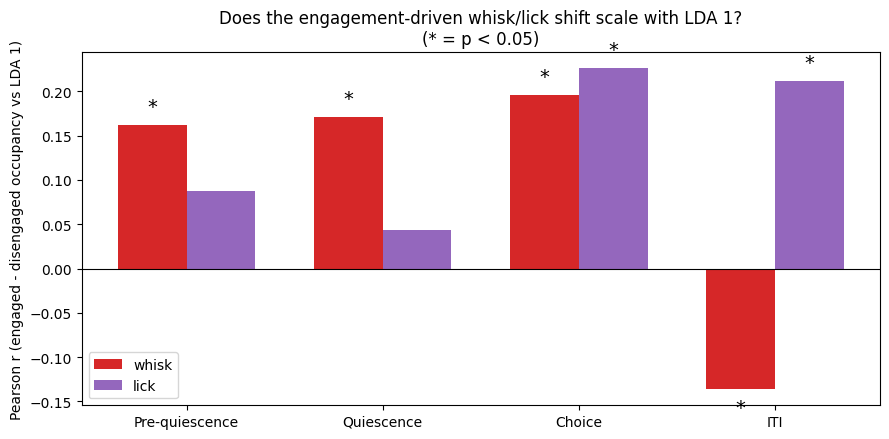

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(EPOCHS))
width = 0.35
colors = {'whisk': 'tab:red', 'lick': 'tab:purple'}
for i, metric in enumerate(['whisk', 'lick']):
    sub = diff_corr_df[diff_corr_df['metric'] == metric].set_index('epoch').reindex(EPOCHS)
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, sub['r'], width, color=colors[metric], label=metric)
    for xi, (r, p) in enumerate(zip(sub['r'], sub['p'])):
        star = '*' if p < 0.05 else ''
        ax.text(x[xi] + offset, r + np.sign(r) * 0.01, star, ha='center',
                va='bottom' if r >= 0 else 'top', fontsize=14)
ax.axhline(0, color='k', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(EPOCHS)
ax.set_ylabel('Pearson r (engaged - disengaged occupancy vs LDA 1)')
ax.set_title('Does the engagement-driven whisk/lick shift scale with LDA 1?\n(* = p < 0.05)')
ax.legend()
plt.tight_layout()
plt.show()

## Partial correlation controlling for session-overall occupancy (exploratory - see caveat above)

In [13]:
overall = session_summary.groupby('session')[['whisk', 'lick']].mean().rename(columns={'whisk': 'whisk_overall', 'lick': 'lick_overall'})
pivot2 = pivot.merge(overall, on='session', how='left')


def residualize(y, x):
    a, b = np.polyfit(x, y, 1)
    return y - (a * x + b)


partial_results = []
for metric in ['whisk', 'lick']:
    for epoch in EPOCHS:
        for state in STATES:
            col, overall_col = f'{metric}_{epoch}_{state}', f'{metric}_overall'
            sub = pivot2[['lda_1', col, overall_col]].dropna()
            resid_val = residualize(sub[col], sub[overall_col])
            resid_lda = residualize(sub['lda_1'], sub[overall_col])
            r, p = pearsonr(resid_lda, resid_val)
            partial_results.append({'metric': metric, 'epoch': epoch, 'state': state, 'n': len(sub), 'r': r, 'p': p})

partial_corr_df = pd.DataFrame(partial_results).sort_values('p').reset_index(drop=True)
partial_corr_df

,metric,epoch,state,n,r,p
0,whisk,Quiescence,state1,244,0.484480,9.138155e-16
1,lick,ITI,state1,244,0.455293,6.877375e-14
2,lick,Pre-quiescence,state2,241,-0.367873,3.884447e-09
3,whisk,Pre-quiescence,state2,241,-0.359092,9.571816e-09
4,whisk,ITI,state1,244,0.353102,1.419394e-08
5,whisk,Choice,state2,241,-0.335039,9.876825e-08
6,lick,Pre-quiescence,state1,244,-0.316383,4.489744e-07
7,lick,Choice,state2,241,-0.167246,9.289909e-03
8,whisk,ITI,state2,241,0.138738,3.131750e-02
9,lick,ITI,state2,241,0.118348,6.663161e-02


# Epoch-duration confound check

Raised concern: if ITI (or any epoch) lasts longer on disengaged trials, the time-pooled
occupancy proportions could be biased by duration rather than reflecting a true behavioral
difference. Checked directly on 40 sessions.

In [14]:
duration_rows = []
for eid in session_eids[:40]:
    beh = load_session_behavior(eid)
    session_states = states_df[states_df['eid'] == eid].reset_index(drop=True)
    trial_id_to_state = dict(zip(session_states.index + beh['trial_id'].min(), session_states['dominant_state']))
    beh['dominant_state'] = beh['trial_id'].map(trial_id_to_state)

    valid = beh.dropna(subset=['trial_id', 'broader_label', 'dominant_state'])
    dur = valid.groupby(['trial_id', 'broader_label']).size().rename('n_bins').reset_index()
    dstate = valid.groupby('trial_id')['dominant_state'].first()
    dur['dominant_state'] = dur['trial_id'].map(dstate)
    duration_rows.append(dur)

duration_df = pd.concat(duration_rows, ignore_index=True)
for epoch in EPOCHS:
    sub = duration_df[duration_df['broader_label'] == epoch]
    g = sub.groupby('dominant_state')['n_bins'].agg(['mean', 'std', 'count'])
    pct = (g.loc['state2', 'mean'] - g.loc['state1', 'mean']) / g.loc['state1', 'mean'] * 100 if 'state2' in g.index and 'state1' in g.index else np.nan
    print(f"{epoch}: state1={g.loc['state1','mean']:.1f} bins, state2={g.loc['state2','mean']:.1f} bins ({pct:+.1f}%)")

Pre-quiescence: state1=47.7 bins, state2=39.9 bins (-16.4%)
Quiescence: state1=31.1 bins, state2=31.0 bins (-0.4%)
Choice: state1=68.0 bins, state2=94.3 bins (+38.6%)
ITI: state1=94.1 bins, state2=93.8 bins (-0.3%)


**Result**: ITI and Quiescence durations are essentially identical between engaged/disengaged
(both <1% difference; ITI is a fixed ~1.55s window regardless of trial outcome) - so the
specific ITI concern doesn't hold here. Pre-quiescence is actually *shorter* on disengaged
trials (-16%), and Choice is ~39% longer on disengaged trials (consistent with slower RT during
lapses). Since occupancy is a time-pooled proportion (already normalized by each trial's own
epoch duration), this natural Choice-duration variability isn't expected to bias the ratio the
way it would a raw count.